This model builds the SMILE model that predicts the atomic charge on each O and H atom for the Mg2+-water-Ne system. The original MD trajectory is contained in `Mg_ion_water_Ne.tar.gz`. In this case, the charge of Mg is fixed to 2+ and Ne fixed to -2/24, where 24 is the total number Ne atoms. The first two sections create the training and testing data containers and build the ACE descriptor matrices from them by reading the raw DFT data. These matrices are saved in the `.npy` files. One can also start directly from the third section `build the ML model`, which read the `.npy` files and build the SMILE model. In this way, the original DFT data and pyiron and pyace packages are not needed. 

In [1]:
from pyiron import Project
import numpy as np
%matplotlib inline
import matplotlib.pylab as plt
import pyace

/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2026-03-02/lib/python3.12/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
plt.rcParams.update(
    {'font.size': 24, 'legend.fontsize': 20, 
     'legend.handlelength': 0.5, 'lines.markersize':10,
     'axes.linewidth':2})

In [3]:
pr = Project('water_Ne')


# train ace potential

In [6]:
tc = pr.create.job.TrainingContainer("Mg_water_data_train_dipole")
phi_train = []
electrode_charge_train = []
#for job_name in ['Mg_water_0', 'Mg_water_1', 'Mg_water_2', 'Mg_water_3', 'Mg_water_4', 'Mg_water_5']:

for job_name in ['Mg_water_0', 'Mg_water_2', 'Mg_water_4']:
    job = pr.load(job_name)
    if job.status.finished:
        try:
            traj = job['output/generic/positions']
            dipole_moment = [i[-1,2] for i in job["output/generic/dft/scf_dipole_mom"]]
            charge = job['output/generic/dft/potentiostat_output']['electrode_charge']
            traj_length = np.shape(traj)[0]
            for i in range(traj_length):
                if i%10 == 0:
                    tc.include_job(job, iteration_step = i)
                    phi_train.append(dipole_moment[i])
                    electrode_charge_train.append(charge[i])
        except:
            continue

2025-03-07 15:42:42,201 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_0', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2025-03-04/lib/python3.11/site-packages/pyiron_snippets/resources.py:297: ResolverWarning: Found file '/cmmc/u/jyang/bin/pyiron-resources-cmmc/vasp/bin/run_vasp_6.4.0_python_gamma_mpi.sh', but skipping it because it is not executable!
  return dict(self.search(name=name))
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2025-03-04/lib/python3.11/site-packages/pyiron_snippets/resources.py:297: ResolverWarning: Found file '/cmmc/u/jyang/bin/pyiron-resources-cmmc/vasp/bin/run_vasp_6.4.0_python_mpi.sh', but skipping it because it is not executable!
  return dict(self.search(name=name))
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2025-03-04/lib/python3.11/site-packages/pyiron_snippets/resources.py:297: ResolverWarning: Found file '/cmmc/u/jyang/bin/pyiron-resources-cmmc/vasp/bin/run_vasp_6.4.0_pyth

In [7]:
np.save("phi_train.npy", phi_train)
np.save("electrode_charge_train.npy", electrode_charge_train)


In [8]:
tc.run(delete_existing_job=True)

2025-03-07 15:43:56,585 - pyiron_log - INFO - run job: Mg_water_data_train_dipole id: None, status: initialized
2025-03-07 15:43:56,588 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_data_train_dipole', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2025-03-07 15:43:56,590 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_data_train_dipole', 'project': '/cmmc/ptmp/jyang/water\\_Ne/water\\_Ne/%'}
2025-03-07 15:43:56,761 - pyiron_log - INFO - run job: Mg_water_data_train_dipole id: 26475611, status: created
2025-03-07 15:43:56,794 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:56,809 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:56,821 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:56,833 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:56,845 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:56,855 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:

The job Mg_water_data_train_dipole was saved and received the ID: 26475611


2025-03-07 15:43:56,961 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:56,973 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:56,984 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:56,994 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:57,005 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:57,015 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:57,026 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:57,038 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:57,050 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:57,063 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:57,074 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:57,085 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-07 15:43:57,095 - pyiron_log - DEBUG - Not supported parameter used!

In [17]:
for num_func in [100, 200, 500]:
    job = pr.create.job.PacemakerJob('pace_maker_job_Mg_repulsive'+str(num_func))
    job.add_training_data(tc)
    job.cutoff=7.0
    job.server.queue = "cmti"
    job.server.cores = 40
    job.input["fit"]["maxiter"] = 1000
    job.input['potential']['functions']["number_of_functions_per_element"] = num_func
    job.input['potential']['embeddings']['ALL']['rho_core_cut'] = 5
    job.input['potential']['embeddings']['ALL']['drho_core_cut'] = 5
    
    job.input['potential']['bonds']['ALL']['r_in'] = 0.9
    job.input['potential']['bonds']['ALL']['delta_in'] = 0.1
    job.input['potential']['bonds']['ALL']['core-repulsion'] = [1e3, 1.0]
    job.run(delete_existing_job=True)

2024-09-09 17:55:46,488 - pyiron_log - INFO - Reconnecting to DB; connection was closed.
2024-09-09 17:55:46,515 - pyiron_log - INFO - run job: pace_maker_job_Mg_repulsive500 id: None, status: initialized
2024-09-09 17:55:46,517 - pyiron_log - DEBUG - sql_query: {'job': 'pace_maker_job_Mg_repulsive500', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2024-09-09 17:55:46,519 - pyiron_log - DEBUG - sql_query: {'job': 'pace_maker_job_Mg_repulsive500', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/%'}
2024-09-09 17:55:54,622 - root - INFO - structure_data is pandas.DataFrame
2024-09-09 17:56:01,343 - root - INFO - Saving training structures dataframe into /cmmc/ptmp/jyang/water_Ne/water_Ne/pace_maker_job_Mg_repulsive500_hdf5/pace_maker_job_Mg_repulsive500/df_fit.pckl.gzip with pickle protocol = 4, compression = gzip
2024-09-09 17:56:04,048 - pyiron_log - INFO - run job: pace_maker_job_Mg_repulsive500 id: 23314795, status: created
2024-09-09 17:56:04,077 - pyiron_log - DEBUG - submitted 

Set automatically determined list of elements: ['H', 'Mg', 'Ne', 'O']
The job pace_maker_job_Mg_repulsive500 was saved and received the ID: 23314795
Queue system id:  9128819


# construct the matrix

In [58]:
tc = pr.load('Mg_water_data_test')
df = tc.to_pandas()


2025-10-13 10:33:07,437 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_data_test', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}


In [9]:
# H Mg Ne O
def make_ace(**kwargs):
    calc = pyace.PyACECalculator(
            '../Mg_200.yaml'
    )
    return calc

In [10]:
def get_descr(ace, structure):
    #del structure.calc
    structure.calc = ace
    structure.get_potential_energy()
    return np.array(structure.calc.ace.projections)

In [11]:
job = pr.load('Mg_water_0')
struct = job.get_structure(-1)

2025-10-10 16:30:04,800 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_0', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2025-10-06/lib/python3.11/site-packages/pyiron_snippets/resources.py:297: ResolverWarning: Found file '/cmmc/u/jyang/bin/pyiron-resources-cmmc/vasp/bin/run_vasp_6.4.0_python_gamma_mpi.sh', but skipping it because it is not executable!
  return dict(self.search(name=name))
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2025-10-06/lib/python3.11/site-packages/pyiron_snippets/resources.py:297: ResolverWarning: Found file '/cmmc/u/jyang/bin/pyiron-resources-cmmc/vasp/bin/run_vasp_6.4.0_python_mpi.sh', but skipping it because it is not executable!
  return dict(self.search(name=name))
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2025-10-06/lib/python3.11/site-packages/pyiron_snippets/resources.py:297: ResolverWarning: Found file '/cmmc/u/jyang/bin/pyiron-resources-cmmc/vasp/bin/run_vasp_6.4.0_pyth

In [12]:
struct.plot3d()

NGLWidget()

In [12]:
ace = make_ace()
d_ace = get_descr(ace, struct)

2025-10-10 16:30:09,208 - pyiron_log - DEBUG - Not supported parameter used!


In [13]:
num_func = np.shape(d_ace)[1]

In [60]:
# position of Mg
n_step = len(df)
z_Mg_list = []
struct = df['atoms'][0]
index_Mg = struct.select_index('Mg')
for i in range(n_step):
    # get the descriptor for each structure
    struct = df['atoms'][i]
    z = struct.positions[index_Mg,2]
    z_Mg_list.append(z[0])

z_Mg_list = np.array(z_Mg_list)
np.save('z_Mg_list_test.npy', z_Mg_list)

In [61]:
z_list_train = []
coeff_matrix_list_train = []
element_list = ['H', 'O']
struct = df['atoms'][0]
num_total_atom = 0
for i, el in enumerate(element_list):
    el_index = struct.select_index(el)
    num_total_atom += len(el_index)
n_element = len(element_list)
n_step = len(df)
d_ace = get_descr(ace, struct)
num_func = np.shape(d_ace)[1]
n_col = num_func*n_element
for i in range(n_step):
    # get the descriptor for each structure
    struct = df['atoms'][i]
    d_ace = get_descr(ace, struct)
    z_list = struct.positions[:,2]
    z_list_shuffle = np.zeros(num_total_atom)
    starting_index = 0
    coeff_matrix = np.zeros((num_total_atom, n_col))
    
    for i, el in enumerate(element_list):
        el_index = struct.select_index(el)
        coeff_matrix[starting_index:starting_index+len(el_index), i*num_func:(i+1)*num_func] = d_ace[el_index]
        z_list_shuffle[starting_index:starting_index+len(el_index)] = z_list[el_index]
        starting_index += len(el_index)
    coeff_matrix_list_train.append(coeff_matrix)
    z_list_train.append(z_list_shuffle)

2025-10-13 10:33:24,186 - pyiron_log - DEBUG - Not supported parameter used!
2025-10-13 10:33:24,229 - pyiron_log - DEBUG - Not supported parameter used!
2025-10-13 10:33:24,267 - pyiron_log - DEBUG - Not supported parameter used!
2025-10-13 10:33:24,303 - pyiron_log - DEBUG - Not supported parameter used!
2025-10-13 10:33:24,338 - pyiron_log - DEBUG - Not supported parameter used!
2025-10-13 10:33:24,373 - pyiron_log - DEBUG - Not supported parameter used!
2025-10-13 10:33:24,408 - pyiron_log - DEBUG - Not supported parameter used!
2025-10-13 10:33:24,442 - pyiron_log - DEBUG - Not supported parameter used!
2025-10-13 10:33:24,491 - pyiron_log - DEBUG - Not supported parameter used!
2025-10-13 10:33:24,524 - pyiron_log - DEBUG - Not supported parameter used!
2025-10-13 10:33:24,560 - pyiron_log - DEBUG - Not supported parameter used!
2025-10-13 10:33:24,594 - pyiron_log - DEBUG - Not supported parameter used!
2025-10-13 10:33:24,629 - pyiron_log - DEBUG - Not supported parameter used!

In [62]:
np.save("coeff_matrix_list_test_Mg_200.npy", coeff_matrix_list_train)
np.save("z_list_test.npy", z_list_train)

In [16]:
np.save("coeff_matrix_list_train_Mg_200.npy", coeff_matrix_list_train)

#np.save("coeff_matrix_list_train_Mg_50.npy", coeff_matrix_list_train)
#np.savetxt("coeff_matrix_list_train_100.csv", np.reshape(coeff_matrix_list_train, (shape[0]*shape[1], shape[2])), delimiter=",")
#np.save("z_list_train.npy", z_list_train)

# build the ML model

## read the matrix

In [31]:
z_list_train = np.load('z_list_train.npy')
phi_train = np.load('phi_train.npy')
z_Mg_list = np.load('z_Mg_list.npy')

In [4]:
z_list_test = np.load('z_list_test.npy')
phi_test = np.load('phi_test.npy')
z_Mg_list_test = np.load('z_Mg_list_test.npy')

In [5]:
coeff_matrix_list_train = np.load('coeff_matrix_list_train_Mg_200.npy')

In [6]:
coeff_matrix_list_test = np.load('coeff_matrix_list_test_Mg_200.npy')

In [32]:
n_element = 2
# H Mg O
z_list_noNe = np.zeros((np.shape(z_list_train)[0], np.shape(z_list_train)[1]))
# -12 Ne atom + 12 surface atom
z_list_noNe[:, 0:126] = z_list_train[:, 0:126] # H
z_list_noNe[:, 126:126+63] = z_list_train[:, 126:126+63] # O 

In [33]:
num_func = int(np.shape(coeff_matrix_list_train)[2]/n_element)
coeff_matrix_list_noNe = np.zeros((np.shape(z_list_train)[0], np.shape(z_list_train)[1], (n_element)*num_func+(n_element)))
coeff_matrix_list_noNe[:, 0:126, 0] = 1   # H
coeff_matrix_list_noNe[:, 0:126, 1:num_func+1] = coeff_matrix_list_train[:, 0:126, 0:num_func]
coeff_matrix_list_noNe[:, 126:126+63, num_func+1] = 1 # O
coeff_matrix_list_noNe[:, 126:126+63, num_func+2:2*num_func+2] = coeff_matrix_list_train[:, 126:126+63, 1*num_func:2*num_func]


In [34]:
coeff_matrix_list_noNe_test = np.zeros((np.shape(z_list_test)[0], np.shape(z_list_test)[1], (n_element)*num_func+(n_element)))
coeff_matrix_list_noNe_test[:, 0:126, 0] = 1   # H
coeff_matrix_list_noNe_test[:, 0:126, 1:num_func+1] = coeff_matrix_list_test[:, 0:126, 0:num_func]
coeff_matrix_list_noNe_test[:, 126:126+63, num_func+1] = 1 # O
coeff_matrix_list_noNe_test[:, 126:126+63, num_func+2:2*num_func+2] = coeff_matrix_list_test[:, 126:126+63, 1*num_func:2*num_func]


## function for training and testing

In [35]:
def train_error(charge_factor, lambda_reg, A_dipole):
    shape = np.shape(coeff_matrix_list_noNe)
    coeff_matrix_double = np.zeros((2*shape[0], shape[1], shape[2]))
    coeff_matrix_double[:shape[0], :, :] = coeff_matrix_list_noNe
    coeff_matrix_double[shape[0]:, :, :] = coeff_matrix_list_noNe
    z_list_double = np.zeros((2*shape[0], shape[1]))
    z_list_double[:shape[0], :] = z_list_noNe
    z_list_double[shape[0]:, 0:189] = charge_factor
    phi_list_double = np.zeros(2*shape[0])
    phi_list_double[:shape[0]] = (phi_train*A_dipole - pos_Ne * (2/24) * 12 - z_Mg_list.T * (-2)) # dipole constraint
    phi_list_double[shape[0]:] = 0 # charge contraint
    mat = np.sum(np.array(coeff_matrix_double).T * np.array(z_list_double).T, axis=1)
    m, n = mat.shape
    I = np.eye(n)
    #mat_inv = np.linalg.pinv(mat, rcond=1e-40)
    mat_inv = np.linalg.inv(mat.T @ mat + lambda_reg * I) @ mat.T
    d_matrix = mat_inv.T@phi_list_double
    charges_predict = np.array(coeff_matrix_list_noNe)@np.array(d_matrix)
    phi_fit = np.sum(charges_predict * z_list_noNe, axis = 1)
    phi_fit_tot = (phi_fit+ pos_Ne * (2/24) * 12 + z_Mg_list * (-2))/A_dipole
    error = np.sqrt(np.mean((phi_train-phi_fit_tot)**2))
    return error, d_matrix, phi_fit_tot

In [36]:
def test_error(d_matrix, A_dipole):
    charges_predict = np.array(coeff_matrix_list_noNe_test)@np.array(d_matrix)
    phi_fit = np.sum(charges_predict * z_list_test, axis = 1)
    phi_fit_tot = (phi_fit + pos_Ne * (2/24) * 12 + z_Mg_list_test * (-2))/A_dipole
    error = np.sqrt(np.mean((phi_test-phi_fit_tot)**2))
    return error, phi_fit_tot

In [37]:
pos_Ne = 24.656269320469203

In [38]:
charge_factor = 10
lambda_reg = 100
A_dipole = 1
error, d_matrix, phi_train_predict = train_error(charge_factor, lambda_reg, A_dipole)
error, phi_test_predict = test_error(d_matrix, A_dipole)

Text(0, 0.5, 'ML $\\mu_z^{tot}\\ (e\\cdot\\mathrm{\\AA})$')

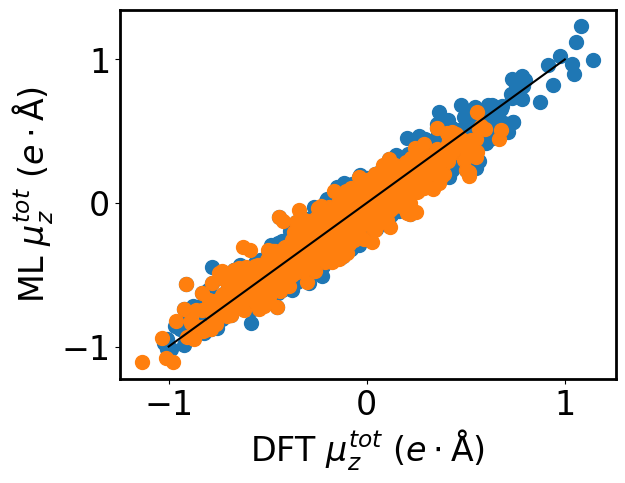

In [41]:
plt.scatter(phi_train, phi_train_predict)
plt.scatter(phi_test, phi_test_predict)
plt.plot([-1, 1], [-1, 1], color = 'Black')

plt.xlabel(r'DFT $\mu_z^{tot}\ (e\cdot\mathrm{\AA})$')
plt.ylabel(r'ML $\mu_z^{tot}\ (e\cdot\mathrm{\AA})$')


In [76]:
struct = df['atoms'][0]

In [77]:
Lx = struct.cell[0][0]
Ly = struct.cell[1][1]
Lz = struct.cell[2][2]

In [78]:
num_total_atom = 189

In [79]:
time_step = 100
struct = df['atoms'][time_step]
charge_step_list = charges_predict[time_step, 0:num_total_atom]
z_step_list = z_list_train[time_step]


In [80]:
z_step_list =  np.append(z_step_list, [z_Mg_list[time_step]])
charge_step_list = np.append(charge_step_list, [-2])

z_Ne = np.zeros(12)
q_Ne = np.ones(12)*(2/24)
z_step_list = np.append(z_step_list, z_Ne)
charge_step_list = np.append(charge_step_list, q_Ne)

z_Ne = np.ones(12)*pos_Ne
q_Ne = np.ones(12)*(2/24)
z_step_list = np.append(z_step_list, z_Ne)
charge_step_list = np.append(charge_step_list, q_Ne)

In [83]:
z, charge_density, pot = calc_el_pot_point_charge(z_step_list, charge_step_list, Lx, Ly, Lz)

In [66]:
np.sum(charge_step_list)

-4.5892158524907245e-05

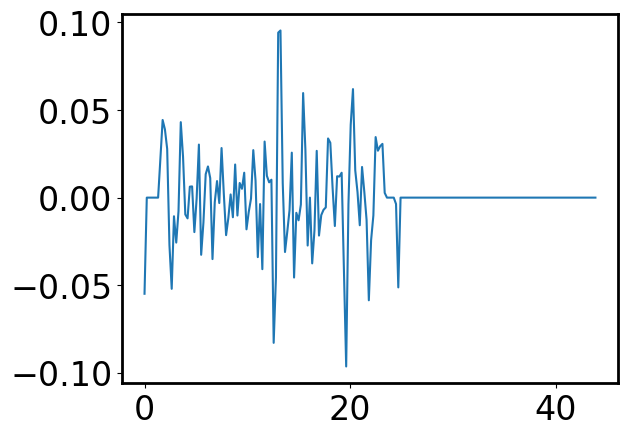

In [84]:
plt.plot(z, charge_density)

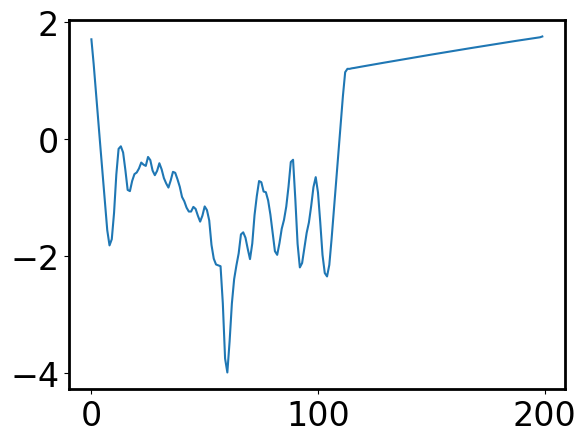

In [85]:
plt.plot(pot)

## take average el_pot

In [86]:
pot_list = []
for time_step in range(1200):
    struct = df['atoms'][time_step]
    charge_step_list = charges_predict[time_step, 0:num_total_atom]
    z_step_list = z_list_train[time_step]   
    z_step_list =  np.append(z_step_list, [z_Mg_list[time_step]])
    charge_step_list = np.append(charge_step_list, [-2])
    
    z_Ne = np.zeros(12)
    q_Ne = np.ones(12)*(2/24)
    z_step_list = np.append(z_step_list, z_Ne)
    charge_step_list = np.append(charge_step_list, q_Ne)
    
    z_Ne = np.ones(12)*pos_Ne
    q_Ne = np.ones(12)*(2/24)
    z_step_list = np.append(z_step_list, z_Ne)
    charge_step_list = np.append(charge_step_list, q_Ne)
    z, charge_density, pot = calc_el_pot_point_charge(z_step_list, charge_step_list, Lx, Ly, Lz)
    pot_list.append(pot)

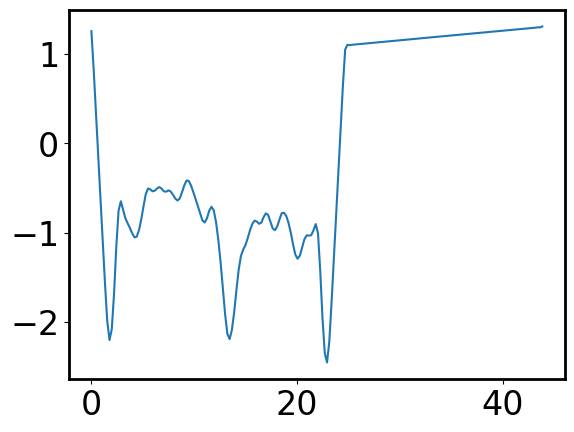

In [87]:
plt.plot(z, np.mean(pot_list, axis = 0))

In [52]:
np.save('pot_z_average_point_charge_alpha1.npy', np.mean(pot_list, axis = 0))

In [11]:
np.shape(charges_predict)

(1200, 189)

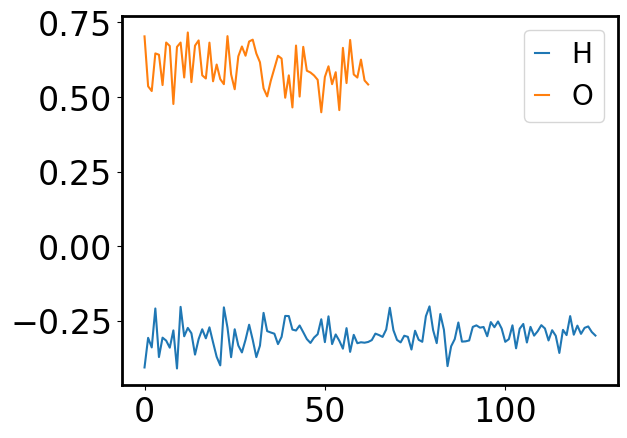

In [88]:
plt.plot(charges_predict[0, 0:63*2], label = 'H')
plt.plot(charges_predict[0, 63*2:63*3], label = 'O')
plt.legend()

In [89]:
def get_charge_list(Lz, charges_step_list, z_step_list, z_Mg, z_Ne, sigma_Mg, sigma_Ne, sigma_O, sigma_H, sigma_Mg_el, sigma_Ne_el, sigma_O_el, sigma_H_el, nz = 648):
    z_list = []
    q_list = []
    sigma_list = []
    # H
    for i in np.arange(0, 63*2):
        z_list.append(z_step_list[i])
        z_list.append(z_step_list[i])
        sigma_list.append(sigma_H)
        sigma_list.append(sigma_H_el)
        q_list.append(1)
        q_list.append(-(charges_step_list[i]+1))
    # O
    for i in np.arange(63*2, 63*3):
        z_list.append(z_step_list[i])
        z_list.append(z_step_list[i])
        sigma_list.append(sigma_O)
        sigma_list.append(sigma_O_el)
        q_list.append(6)
        q_list.append(-(charges_step_list[i]+6))
    # Mg
    z_list.append(z_Mg)
    z_list.append(z_Mg)
    sigma_list.append(sigma_Mg)
    sigma_list.append(sigma_Mg_el)
    q_list.append(8)
    q_list.append(-6)    

    for i in range(12):
        z_list.append(0)
        z_list.append(0)
        sigma_list.append(sigma_Ne)
        sigma_list.append(sigma_Ne_el)
        q_list.append((8-2/24))
        q_list.append(-8)
        z_list.append(z_Ne)
        z_list.append(z_Ne)
        sigma_list.append(sigma_Ne)
        sigma_list.append(sigma_Ne_el)
        q_list.append((8-2/24))
        q_list.append(-8)
        
    return z_list, q_list, sigma_list

In [90]:
def get_charge_list_shift(Lz, charges_step_list, z_step_list, z_Mg, z_Ne, sigma_Mg, sigma_Ne, sigma_O, sigma_H, sigma_Mg_el, sigma_Ne_el, sigma_O_el, sigma_H_el, alpha_O, alpha_H, alpha_Mg, alpha_Ne, total_dipole, nz = 648, shift = True):
    z_list = []
    q_list = []
    sigma_list = []
    # H
    for i in np.arange(0, 63*2):
        z_list.append(z_step_list[i])
        if shift == True: 
            z_list.append(z_step_list[i] + alpha_H * total_dipole/(charges_step_list[i]+1))
        else:
            z_list.append(z_step_list[i])
        sigma_list.append(sigma_H)
        sigma_list.append(sigma_H_el)
        q_list.append(1)
        q_list.append(-(charges_step_list[i]+1))
    # O
    for i in np.arange(63*2, 63*3):
        z_list.append(z_step_list[i])
        if shift == True: 
            z_list.append(z_step_list[i] + alpha_O * total_dipole/(charges_step_list[i]+6))
        else:
            z_list.append(z_step_list[i])
        sigma_list.append(sigma_O)
        sigma_list.append(sigma_O_el)
        q_list.append(6)
        q_list.append(-(charges_step_list[i]+6))
    # Mg
    z_list.append(z_Mg)
    if shift == True: 
        z_list.append(z_Mg + alpha_Mg * total_dipole/(6))
    else:
        z_list.append(z_Mg)
    sigma_list.append(sigma_Mg)
    sigma_list.append(sigma_Mg_el)
    q_list.append(8)
    q_list.append(-6)    

    for i in range(12):
        z_list.append(0)
        if shift == True: 
            z_list.append(0 + alpha_Ne * total_dipole/(8))
        else:
            z_list.append(0)
        sigma_list.append(sigma_Ne)
        sigma_list.append(sigma_Ne_el)
        q_list.append((8-2/24))
        q_list.append(-8)
        z_list.append(z_Ne)
        if shift == True: 
            z_list.append(z_Ne + alpha_Ne * total_dipole/(8))
        else:
            z_list.append(z_Ne)
        sigma_list.append(sigma_Ne)
        sigma_list.append(sigma_Ne_el)
        q_list.append((8-2/24))
        q_list.append(-8)
        
    return z_list, q_list, sigma_list

In [38]:
step_index_list = np.array([  90,  120,  180,  210,  270,  300,  330,  360,  390,  420,  480,
        540,  570,  630,  720,  870,  930,  960,  990, 1020, 1050, 1080,
       1110, 1170])

In [39]:
pot_dft_list = np.load('pot_dft_Mg_20frame.npy')

In [40]:
plot_index = 14
step_index = step_index_list[plot_index]
time_step = step_index

In [73]:

struct = df['atoms'][time_step]
charge_step_list = charges_predict[time_step]
z_step_list = z_list_train[time_step]   
z_Mg = z_Mg_list[time_step]

sigma_Mg = 0.8
sigma_H = 0.30857
sigma_O = 0.30857
sigma_Ne = 1.3/4

sigma_H_el = sigma_H*1.53
sigma_O_el = sigma_O*1.53
sigma_Ne_el = 0.45#0.45
sigma_Mg_el = sigma_Mg*1.1

z_Ne = 24.656269320469203

z_list, q_list, sigma_list = get_charge_list(struct, charge_step_list, z_step_list, z_Mg, z_Ne, sigma_Mg, sigma_Ne, sigma_O, sigma_H, sigma_Mg_el, sigma_Ne_el, sigma_O_el, sigma_H_el)
    

In [439]:
struct.cell[1][1]

9.773464

In [42]:
Lx = 8.464068
Ly = 9.773464
Lz = 44.055096

In [43]:
def gaussian_charge_density(q_list, z_list, sigma_list, Lz, nz):
    """
    Compute the total charge density on a 1D grid due to multiple Gaussian charges.

    Parameters:
        q_list (list or array): List of total charges for each Gaussian.
        z_list (list or array): List of positions for each Gaussian.
        sigma_list (list or array): List of standard deviations (spreads) for each Gaussian.
        Lz (float): Total length of the 1D grid.
        nz (int): Number of grid points.

    Returns:
        rho (np.ndarray): Charge density array of length nz.
        z_grid (np.ndarray): Corresponding z-coordinates of the grid.
    """
    z_grid = np.linspace(0, Lz, nz, endpoint = False)
    dz = z_grid[1] - z_grid[0]
    rho = np.zeros_like(z_grid)
    n_roll = 90
    z_roll = n_roll*dz
    for q, z0, sigma in zip(q_list, z_list, sigma_list):
        # Gaussian function normalized to have total charge q
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((z_grid - (z0+z_roll)) / sigma)**2)
        rho += gaussian
    rho = np.roll(rho, -n_roll)
    return rho, z_grid

In [74]:
rho, z_grid = gaussian_charge_density(q_list, z_list, sigma_list, Lz, nz = 648)

In [45]:
def calc_el_pot_1d(charge_density, Lx, Ly, Lz, epsilon_0=0.005526349358057108):
    n_grid = len(charge_density)
    dz = Lz/n_grid
    # Fourier transform of charge density
    rho_k = np.fft.fft(charge_density/Lx/Ly)

    # Define wave numbers (k-space grid)
    k = 2 * np.pi * np.fft.fftfreq(n_grid, d=dz)

    # Solve Poisson’s equation in Fourier space: ϕ_k = -ρ_k / (ε₀ k²)
    phi_k = np.zeros_like(rho_k, dtype=np.complex128)
    
    # Avoid division by zero at k=0 (mean charge mode)
    mask = k != 0
    phi_k[mask] = -rho_k[mask] / (epsilon_0 * k[mask]**2)

    # Transform back to real space
    phi = np.real(np.fft.ifft(phi_k))

    return phi   

In [75]:
dipole_shift, rho_corr = calc_dipole_1d(rho, Lz, 648, gridposition=550, grid_roll = 100)  


In [76]:
phi = calc_el_pot_1d(rho, Lx, Ly, Lz, epsilon_0=0.005526349358057108)

phi_corr = calc_el_pot_1d(rho_corr, Lx, Ly, Lz, epsilon_0=0.005526349358057108)
    

In [77]:
alpha = 1/702

In [78]:
alpha_O = alpha
alpha_H = alpha
alpha_Mg = alpha
alpha_Ne = alpha


sigma_Mg = 0.8
sigma_H = 0.30857
sigma_O = 0.30857
sigma_Ne = 1.3/4

sigma_H_el = sigma_H*1.53
sigma_O_el = sigma_O*1.53
sigma_Ne_el = 0.46#0.45
sigma_Mg_el = sigma_Mg*1.1

In [79]:
delta_dipole = (phi_fit[time_step]+ pos_Ne * (2/24) * 12 + (-2)*z_Mg_list[time_step])*-1.25
z_list, q_list, sigma_list = get_charge_list_shift(struct, charge_step_list, z_step_list, z_Mg, z_Ne, sigma_Mg, sigma_Ne, sigma_O, sigma_H, sigma_Mg_el, sigma_Ne_el, sigma_O_el, sigma_H_el, alpha_O, alpha_H, alpha_Mg, alpha_Ne, delta_dipole, shift = True)
rho_shift, z_grid = gaussian_charge_density(q_list, z_list, sigma_list, Lz, nz = 648)  
dipole_shift, rho_corr_shift = calc_dipole_1d(rho_shift, Lz, 648, gridposition=550, grid_roll = 100)  
phi_corr_shift = calc_el_pot_1d(rho_corr_shift, Lx, Ly, Lz, epsilon_0=0.005526349358057108)


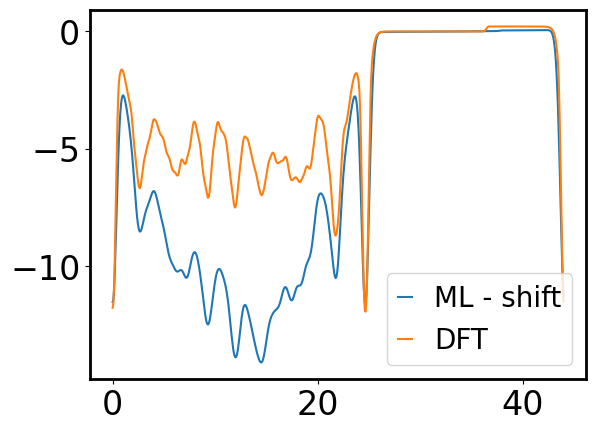

In [80]:
#plt.plot(z_grid, phi)
plt.plot(z_grid, phi_corr_shift - phi_corr_shift[500], label = 'ML - shift')
#plt.plot(z_grid, phi_corr - phi_corr[500], label = 'ML - no shift')
plt.plot(z_grid,  pot_dft_list[plot_index] - pot_dft_list[plot_index][500], label = 'DFT')
plt.legend()

In [165]:
pot_dft_list = np.load('pot_dft_Mg_20frame.npy')

In [395]:
step_index_list = np.array([  90,  120,  180,  210,  270,  300,  330,  360,  390,  420,  480,
        540,  570,  630,  720,  870,  930,  960,  990, 1020, 1050, 1080,
       1110, 1170])

In [166]:
np.shape(pot_dft_list)

(24, 648)

In [405]:

sigma_Mg = 0.8
sigma_H = 0.30857
sigma_O = 0.30857
sigma_Ne = 1.3/4

sigma_H_el = sigma_H*1.53
sigma_O_el = sigma_O*1.53
sigma_Ne_el = 0.46#0.45
sigma_Mg_el = sigma_Mg*1.1


phi_list =[]
for time_step in step_index_list:
    struct = df['atoms'][time_step]
    charge_step_list = charges_predict[time_step]
    z_step_list = z_list_train[time_step]   
    z_Mg = z_Mg_list[time_step]
    z_list, q_list, sigma_list = get_charge_list(struct, charge_step_list, z_step_list, z_Mg, z_Ne, sigma_Mg, sigma_Ne, sigma_O, sigma_H, sigma_Mg_el, sigma_Ne_el, sigma_O_el, sigma_H_el)
    rho, z_grid = gaussian_charge_density(q_list, z_list, sigma_list, Lz, nz = 648)
    phi = calc_el_pot_1d(rho, Lx, Ly, Lz, epsilon_0=0.005526349358057108)
    phi_list.append(phi)

In [406]:
phi_ave = np.mean(phi_list, axis = 0)

In [407]:
phi_dft_average = np.mean(pot_dft_list, axis = 0)

In [163]:
ave_pot_aimd = np.load('../with_water_dipole/Mg_water_AIMD_ave.npy')
z_ave_pot_aimd = np.linspace(0, Lz, len(ave_pot_aimd))

Text(0, 0.5, 'el pot')

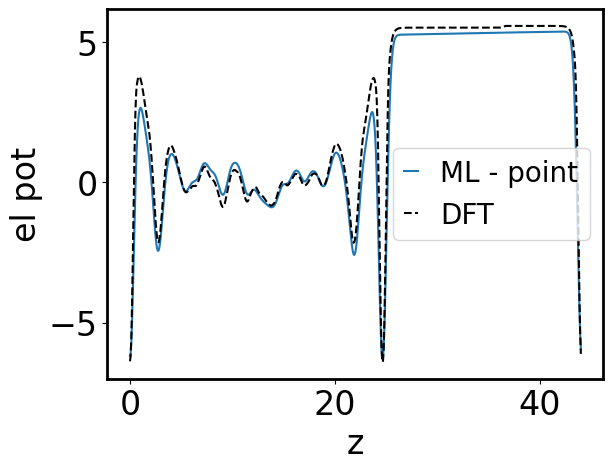

In [450]:
plt.plot(z_grid, phi_ave - np.mean(phi_ave[40:320]), label = 'ML - point')
plt.plot(z_grid, phi_dft_average   - np.mean(phi_dft_average[40:320]),'--', label = 'DFT', color = 'Black')
#plt.plot(z_ave_pot_aimd, ave_pot_aimd - ave_pot_aimd[500], '--', color = 'Black', label = 'AIMD')
#plt.axvline(z_grid[40])
#plt.axvline(z_grid[200])
#plt.axvline(z_grid[320])
plt.legend()
plt.xlabel('z')
plt.ylabel('el pot')

In [361]:
def get_total_el_pot_diff(sigma_O_el, sigma_H_el, sigma_Mg_el, sigma_Ne_el):
    phi_list =[]
    error_list = []
    for i, time_step in enumerate(step_index_list):
        struct = df['atoms'][time_step]
        charge_step_list = charges_predict[time_step]
        z_step_list = z_list_train[time_step]   
        z_Mg = z_Mg_list[time_step]
        delta_dipole = (phi_fit[time_step]+ pos_Ne * (2/24) * 12 + (-2)*z_Mg_list[time_step])*-1.25
        z_list, q_list, sigma_list = get_charge_list_shift(struct, charge_step_list, z_step_list, z_Mg, z_Ne, sigma_Mg, sigma_Ne, sigma_O, sigma_H, sigma_Mg_el, sigma_Ne_el, sigma_O_el, sigma_H_el, alpha_O, alpha_H, alpha_Mg, alpha_Ne, delta_dipole, shift = True)
        rho, z_grid = gaussian_charge_density(q_list, z_list, sigma_list, Lz, nz = 648)
        dipole_shift, rho_corr_shift = calc_dipole_1d(rho, Lz, 648, gridposition=550, grid_roll = 100)  
        phi = calc_el_pot_1d(rho_corr_shift, Lx, Ly, Lz, epsilon_0=0.005526349358057108)
        phi_list.append(phi)    
        phi_diff = (phi - np.mean(phi[40:320])) - (pot_dft_list[i] - np.mean(pot_dft_list[i][40:320]))
        error = np.linalg.norm(phi_diff)
        error_list.append(error)
    return phi_list, error_list

In [362]:
sigma_Mg = 0.8
sigma_H = 0.30857
sigma_O = 0.30857
sigma_Ne = 1.3/4

sigma_H_el = sigma_H*1.4
sigma_O_el = sigma_O*1.4
sigma_Ne_el = 0.45
sigma_Mg_el = sigma_Mg*1.1

In [366]:
sigma_el_list = np.linspace(1.2, 1.8, 10)
error_list = []
for sigma_el in sigma_el_list:
    sigma_H_el = sigma_H*sigma_el
    sigma_O_el = sigma_O*sigma_el
    phi_list, error = get_total_el_pot_diff(sigma_O_el, sigma_H_el, sigma_Mg_el, sigma_Ne_el)
    error_list.append(error)

In [367]:
np.shape(error_list)

(10, 24)

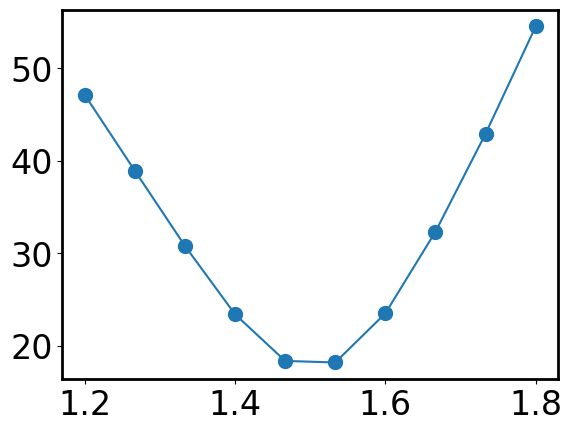

In [368]:
plt.plot(sigma_el_list, np.mean(error_list, axis = 1), '-o')

In [369]:

sigma_el_list[np.argmin(np.mean(error_list, axis = 1))]

1.5333333333333332

In [45]:
el_pot_dft = np.load('../../Mg_wannier_20frame/Mg_water_20frame_pot_dft.npy')

In [57]:
Lx = struct.cell[0][0]
Ly = struct.cell[1][1]
Lz = struct.cell[2][2]

In [58]:
step_index_list = np.arange(0, 1200, 30)[1:]

In [81]:
plot_index = 16
step_index = step_index_list[plot_index]


sigma_Mg = 2/6
sigma_H = 1.1/6
sigma_O = 1.52/6
sigma_Ne = 1.7/6

sigma_H_el = sigma_H*1.8
sigma_O_el = sigma_O*1.8
sigma_Ne_el = sigma_Ne*1.6
sigma_Mg_el = sigma_Mg*1.5



#sigma_Mg = 2/6
#sigma_H = 0.75
#sigma_O = 0.75*1.1
#sigma_Ne = 1.7/6

#sigma_H_el = 0.63
#sigma_O_el = 0.63*1.1
#sigma_Ne_el = sigma_Ne*1.6
#sigma_Mg_el = sigma_Mg*1.5

z_Ne = 24.656269320469203

phi_list =[]

struct = df['atoms'][step_index]
charge_step_list = charges_predict[step_index]
z_step_list = z_list_train[step_index]   
z_Mg = z_Mg_list[step_index]
z_list, q_list, sigma_list = get_charge_list(struct, charge_step_list, z_step_list, z_Mg, z_Ne, sigma_Mg, sigma_Ne, sigma_O, sigma_H, sigma_Mg_el, sigma_Ne_el, sigma_O_el, sigma_H_el)
rho, z_grid = gaussian_charge_density(q_list, z_list, sigma_list, Lz, nz = 648*2)
phi = calc_el_pot_1d(rho, Lx, Ly, Lz, epsilon_0=0.005526349358057108)

In [82]:
dft_locpot = pr.load('Mg_water_20frame_locpot_'+str(step_index))
locpot = dft_locpot.get_electrostatic_potential()

2025-05-19 10:06:37,593 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_20frame_locpot_510', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2025-05-19 10:06:37,608 - pyiron_log - INFO - Reconnecting to DB; connection was closed.


Text(0, 0.5, 'el pot')

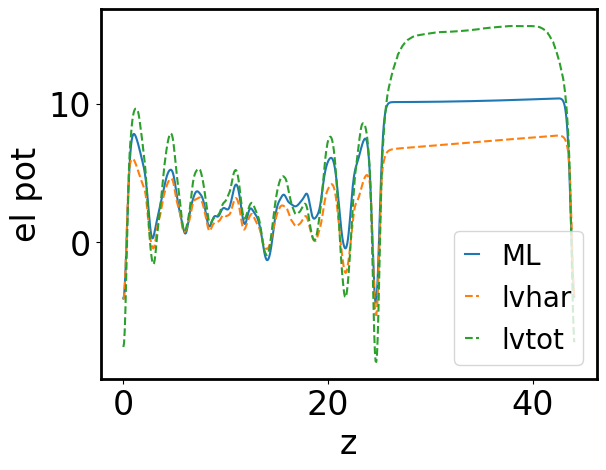

In [83]:
z = np.linspace(0, Lz, 648*2)
plt.plot(z, phi - phi[400], label = 'ML')
z = np.linspace(0, Lz, 648)
plt.plot(z, el_pot_dft[plot_index] - el_pot_dft[plot_index][200], '--', label = 'lvhar')

plt.plot(z, locpot.get_average_along_axis(2)- locpot.get_average_along_axis(2)[200], '--', label = 'lvtot')

#plt.axvline(z[200])
#plt.axvline(z[350])
plt.legend()
plt.xlabel('z')
plt.ylabel('el pot')

In [51]:
sigma_water_el_list = np.linspace(0.1, 1.5, 30)
sigma_water_list = np.linspace(0.05, 1, 20)
error_list = np.zeros((30, 20))


for i in range(30):
    sigma_H_el = sigma_water_el_list[i]
    sigma_O_el = sigma_water_el_list[i]*1.1
    for j in range(20):
        sigma_H = sigma_water_list[j]
        sigma_O = sigma_water_list[j]*1.1
        z_list, q_list, sigma_list = get_charge_list(struct, charge_step_list, z_step_list, z_Mg, z_Ne, sigma_Mg, sigma_Ne, sigma_O, sigma_H, sigma_Mg_el, sigma_Ne_el, sigma_O_el, sigma_H_el)
        rho, z_grid = gaussian_charge_density(q_list, z_list, sigma_list, Lz, nz = 648)
        phi = calc_el_pot_1d(rho, Lx, Ly, Lz, epsilon_0=0.005526349358057108)
        error = np.sum(np.abs(phi - phi[200] - el_pot_dft[plot_index] + el_pot_dft[plot_index][200])[30:350])
        error_list[i,j] = error

In [52]:
np.unravel_index(np.argmin(error_list), error_list.shape)

(15, 19)

In [71]:
sigma_water_el_list[11]

0.6310344827586206

In [72]:
np.argmin(error_list[11])

14

In [73]:
sigma_water_list[14]

0.75

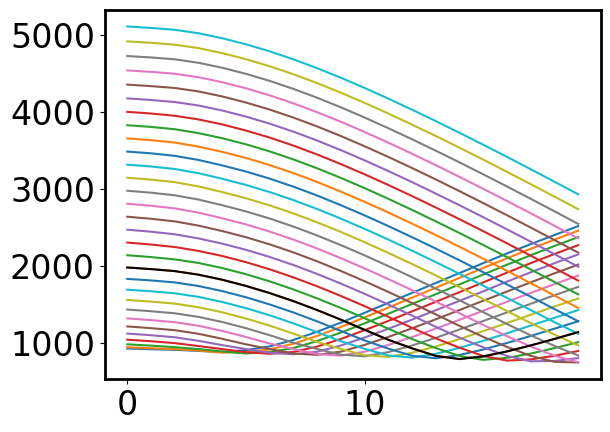

In [63]:
plt.plot(error_list.T);
plt.plot(error_list[11], color = 'Black');

In [85]:
def get_charge_list(Lz, charges_step_list, z_step_list, z_Mg, z_Ne, sigma_Mg, sigma_Ne, sigma_O, sigma_H, sigma_Mg_el, sigma_Ne_el, sigma_O_el, sigma_H_el, nz = 648, charge_mul = 1):
    z_list = []
    q_list = []
    sigma_list = []
    # H
    for i in np.arange(0, 63*2):
        z_list.append(z_step_list[i])
        z_list.append(z_step_list[i])
        sigma_list.append(sigma_H)
        sigma_list.append(sigma_H_el)
        q_list.append(1)
        q = -((charges_step_list[i]-1)*charge_mul+1)
        q_list.append(q)
    # O
    for i in np.arange(63*2, 63*3):
        z_list.append(z_step_list[i])
        z_list.append(z_step_list[i])
        sigma_list.append(sigma_O)
        sigma_list.append(sigma_O_el)
        q_list.append(6)
        q = -((charges_step_list[i]-6)*charge_mul + 6)
        q_list.append(q)
    # Mg
    z_list.append(z_Mg)
    z_list.append(z_Mg)
    sigma_list.append(sigma_Mg)
    sigma_list.append(sigma_Mg_el)
    q_list.append(8)
    q_list.append(-6)    

    for i in range(12):
        z_list.append(0)
        z_list.append(0)
        sigma_list.append(sigma_Ne)
        sigma_list.append(sigma_Ne_el)
        q_list.append((8-2/24))
        q_list.append(-8)
        z_list.append(z_Ne)
        z_list.append(z_Ne)
        sigma_list.append(sigma_Ne)
        sigma_list.append(sigma_Ne_el)
        q_list.append((8-2/24))
        q_list.append(-8)
        
    return z_list, q_list, sigma_list

In [114]:
plot_index = 2
step_index = step_index_list[plot_index]

sigma_Mg = 2/6
sigma_H = 1.1/7
sigma_O = 1.52/7
sigma_Ne = 1.7/6

sigma_H_el = sigma_H*1.7
sigma_O_el = sigma_O*1.7
sigma_Ne_el = sigma_Ne*1.6
sigma_Mg_el = sigma_Mg*1.5


phi_list =[]

struct = df['atoms'][step_index]
charge_step_list = charges_predict[step_index]
z_step_list = z_list_train[step_index]   
z_Mg = z_Mg_list[step_index]
z_list, q_list, sigma_list = get_charge_list(struct, charge_step_list, z_step_list, z_Mg, z_Ne, sigma_Mg, sigma_Ne, sigma_O, sigma_H, sigma_Mg_el, sigma_Ne_el, sigma_O_el, sigma_H_el, charge_mul = 1.4)
rho, z_grid = gaussian_charge_density(q_list, z_list, sigma_list, Lz, nz = 648)
phi = calc_el_pot_1d(rho, Lx, Ly, Lz, epsilon_0=0.005526349358057108)

Text(0, 0.5, 'el pot')

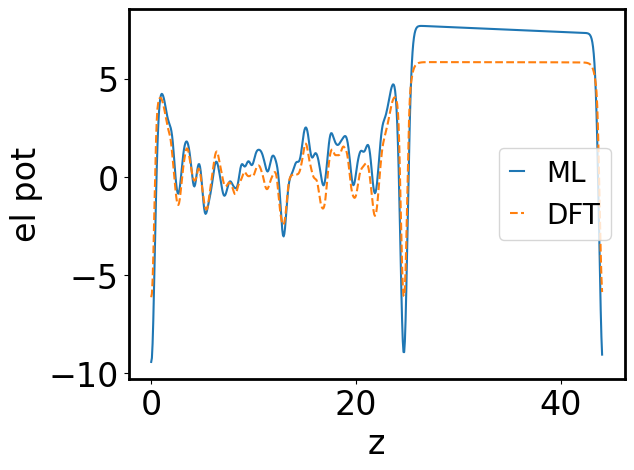

In [115]:
z = np.linspace(0, Lz, 648)
plt.plot(z, phi - phi[200], label = 'ML')

plt.plot(z, el_pot_dft[plot_index] - el_pot_dft[plot_index][200], '--', label = 'DFT')

#plt.axvline(z[200])
#plt.axvline(z[350])
plt.legend()
plt.xlabel('z')
plt.ylabel('el pot')

In [8]:
struct = df['atoms'][0]

In [9]:
Lx = struct.cell[0][0]
Ly = struct.cell[1][1]
Lz = struct.cell[2][2]

In [10]:
num_total_atom = 189

In [8]:
charges_predict = np.load('charge_predict_alpha100.npy')
z_list_train = np.load('z_list_train.npy')

In [12]:
time_step = 100
struct = df['atoms'][time_step]
charge_step_list = charges_predict[time_step, 0:num_total_atom]
z_step_list = z_list_train[time_step]


In [13]:
index_O = struct.select_index('O')
index_H = struct.select_index('H')

In [50]:
index_O = struct.select_index('O')
index_H = struct.select_index('H')
index_Mg = struct.select_index('Mg')[0]

nn = struct.get_neighbors(num_neighbors=2)
water_molecule_charge_list = []
water_molecule_dipole_list = []
Mg_O_dis_list = []
for iO in index_O:
    iH1 = nn.indices[iO][0]
    iH2 = nn.indices[iO][1]
    assert iH1 in index_H
    assert iH2 in index_H
    if iO < 149:
        iO_charge = iO - 12
    else:
        iO_charge = iO - 13
    water_charge = charges_predict[time_step][iO_charge] + \
    charges_predict[time_step][iH1] + \
    charges_predict[time_step][iH2] 
    water_molecule_charge_list.append(water_charge - 8)
    d_Mg_O = struct.get_distance(iO, index_Mg)
    Mg_O_dis_list.append(d_Mg_O)
    pos_O = struct.positions[iO]
    pos_H1 = struct.positions[iH1]
    pos_H2 = struct.positions[iH2]
    #qO = charges_predict[time_step][iO_charge]-6
    #qH1 = charges_predict[time_step][iH1]-1
    #qH2 = charges_predict[time_step][iH2]-1
    qO = 0.38
    qH1 = -0.19
    qH2 = -0.19
    dipole = pos_O * qO + \
    pos_H1 * qH1 + \
    pos_H2 * qH2
    water_molecule_dipole_list.append(dipole)
    
    

2025-03-13 13:40:54,305 - pyiron_log - DEBUG - Not supported parameter used!


Text(0.5, 0, 'dipole norm')

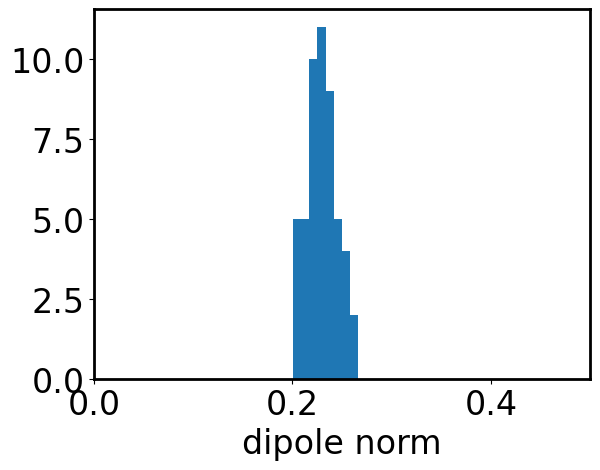

In [53]:
plt.hist(np.linalg.norm(water_molecule_dipole_list, axis = 1), bins = 200);
plt.xlim(0, 0.5)
plt.xlabel('dipole norm')

Text(0, 0.5, 'electron charge')

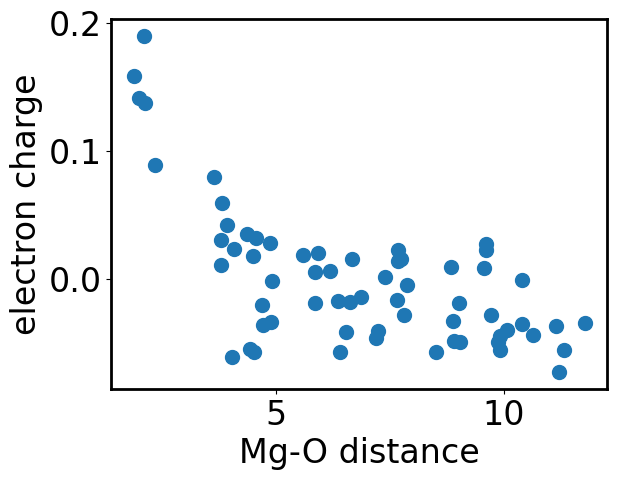

In [30]:
plt.plot(Mg_O_dis_list, water_molecule_charge_list,'o')
plt.xlabel('Mg-O distance')
plt.ylabel('electron charge')

In [22]:
tc = pr.create.job.TrainingContainer("Mg_water_data_test")
phi_test = []
electrode_charge_test = []
for job_name in ['Mg_water_2']:
    job = pr.load(job_name)
    if job.status.finished:
        try:
            traj = job['output/generic/positions']
            dipole_moment = [i[-1,2] for i in job["output/generic/dft/scf_dipole_mom"]]
            charge = job['output/generic/dft/potentiostat_output']['electrode_charge']
            traj_length = np.shape(traj)[0]
            for i in range(traj_length):
                if i%5 == 0:
                    tc.include_job(job, iteration_step = i)
                    phi_test.append(dipole_moment[i])
                    electrode_charge_test.append(charge[i])
        except:
            continue

2024-07-31 10:00:54,130 - pyiron_log - INFO - Reconnecting to DB; connection was closed.
2024-07-31 10:00:54,140 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_2', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2024-07-31 10:00:58,204 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_2', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2024-07-31 10:00:58,260 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_2', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2024-07-31 10:00:58,313 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_2', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2024-07-31 10:00:58,365 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_2', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2024-07-31 10:00:58,417 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_2', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2024-07-31 10:00:58,469 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_2', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2

In [23]:
np.save("phi_test.npy", phi_test)
np.save("electrode_charge_test.npy", electrode_charge_test)

In [24]:
tc.run(delete_existing_job=True)

2024-07-31 10:02:47,054 - pyiron_log - INFO - Reconnecting to DB; connection was closed.
2024-07-31 10:02:47,060 - pyiron_log - INFO - run job: Mg_water_data_test id: None, status: initialized
2024-07-31 10:02:47,062 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_data_test', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2024-07-31 10:02:47,064 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_data_test', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/%'}
2024-07-31 10:02:47,285 - pyiron_log - INFO - run job: Mg_water_data_test id: 23030956, status: created
2024-07-31 10:02:47,310 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,324 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,337 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,349 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,362 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,374 - pyiron_log - DE

The job Mg_water_data_test was saved and received the ID: 23030956


2024-07-31 10:02:47,488 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,501 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,513 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,526 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,538 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,551 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,563 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,576 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,589 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,601 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,613 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,626 - pyiron_log - DEBUG - Not supported parameter used!
2024-07-31 10:02:47,638 - pyiron_log - DEBUG - Not supported parameter used!

In [25]:
tc = pr.load('Mg_water_data_test')
df = tc.to_pandas()


2024-07-31 10:03:08,122 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_data_test', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}


In [26]:
z_list_test = []
coeff_matrix_list_test = []
element_list = ['H', 'O', 'Mg']
struct = df['atoms'][0]
num_total_atom = 0
for i, el in enumerate(element_list):
    el_index = struct.select_index(el)
    num_total_atom += len(el_index)
n_element = len(element_list)
n_step = len(df)
d_ace = get_descr(ace, struct)
num_func = np.shape(d_ace)[1]
n_col = num_func*n_element
for i in range(n_step):
    # get the descriptor for each structure
    struct = df['atoms'][i]
    z_list = struct.positions[:,2]
    z_list_shuffle = np.zeros(num_total_atom)
    starting_index = 0
    coeff_matrix = np.zeros((num_total_atom, n_col))
    for i, el in enumerate(element_list):
        el_index = struct.select_index(el)
        coeff_matrix[starting_index:starting_index+len(el_index), i*num_func:(i+1)*num_func] = d_ace[el_index]
        z_list_shuffle[starting_index:starting_index+len(el_index)] = z_list[el_index]
        starting_index += len(el_index)
    coeff_matrix_list_test.append(coeff_matrix)
    z_list_test.append(z_list_shuffle)

2024-07-31 10:03:16,212 - pyiron_log - DEBUG - Not supported parameter used!


In [27]:
shape = np.shape(coeff_matrix_list_test)
np.save("coeff_matrix_list_test_Mg_50.npy", coeff_matrix_list_test)
np.save("z_list_test.npy", z_list_test)

In [80]:
z_list_test = np.loadtxt('../training_and_test/z_list_test.csv', delimiter= ',')
phi_test = np.loadtxt('../training_and_test/phi_test.csv', delimiter= ',')

In [10]:
coeff_matrix_list_test = np.loadtxt('../training_and_test/coeff_matrix_list_test_50.csv', delimiter= ',')
coeff_matrix_list_test = np.reshape(coeff_matrix_list_test, (np.shape(z_list_test)[0], np.shape(z_list_test)[1], np.shape(coeff_matrix_list_test)[1]))

In [11]:
z_list_test = np.array(z_list_test)
coeff_matrix_list_test = np.array(coeff_matrix_list_test)

In [81]:
n_element = 4

z_list_noNe_test = np.zeros((np.shape(z_list_test)[0], np.shape(z_list_test)[1]))
# -12 Ne atom + 12 surface atom

z_list_noNe_test[:, 0:128] = z_list_test[:, 0:128] # H
z_list_noNe_test[:, 128:128+64] = z_list_test[:, 140:140+64] # O 
z_list_noNe_test[:, 192: 192+36] = z_list_test[:, 204:204+36]
z_list_noNe_test[:, 192+36:192+48] = 0
z_list_noNe_test[:, 192+48:] = 1  #z_list_train[:, 240:] 

#z_list_noNe[:, 192: 192+48] = z_list_train[:, 204:]   # Pt atoms
#z_list_noNe[:, 192+48:] = z_list_train[:, 240:] + 0.5   # Pt atoms


In [12]:
num_func = int(np.shape(coeff_matrix_list_test)[2]/n_element)

coeff_matrix_list_noNe_test = np.zeros((np.shape(z_list_test)[0], np.shape(z_list_test)[1], (n_element)*num_func+(n_element)))

coeff_matrix_list_noNe_test[:, 0:128, 0] = 1   # H
coeff_matrix_list_noNe_test[:, 0:128, 1:num_func+1] = coeff_matrix_list_test[:, 0:128, 0:num_func]
coeff_matrix_list_noNe_test[:, 128:128+64, num_func+1] = 1 # O
coeff_matrix_list_noNe_test[:, 128:128+64, num_func+2:2*num_func+2] = coeff_matrix_list_test[:, 140:140+64, 2*num_func:3*num_func]
coeff_matrix_list_noNe_test[:, 192:192+48, 2*num_func+2] = 1 # Pt
coeff_matrix_list_noNe_test[:, 192:192+48, 2*num_func+3: 3*num_func+3] = coeff_matrix_list_test[:, 204:, 3*num_func:4*num_func]
coeff_matrix_list_noNe_test[:, 192+48:, 3*num_func+3] = 1 # Pt - dipole
coeff_matrix_list_noNe_test[:, 192+48:, 3*num_func+4:] = coeff_matrix_list_test[:, 240:, 3*num_func:4*num_func]

In [75]:
charges_predict = np.array(coeff_matrix_list_noNe_test)@np.array(d_matrix)
phi_fit = np.sum(charges_predict * z_list_noNe_test, axis = 1)

NameError: name 'coeff_matrix_list_noNe_test' is not defined

In [252]:
error = np.linalg.norm(phi_fit - phi_test)

In [253]:
error/len(phi_test)

0.010861238058281111

In [254]:
total_charge = np.sum(charges_predict, axis = 1)
np.linalg.norm(total_charge/len(total_charge))

2.1609685259936483e-07

In [68]:
charges_predict = np.loadtxt('charge_predict_200_test.csv', delimiter = ',')

In [82]:
phi_fit = np.sum(charges_predict * z_list_noNe_test, axis = 1)